# EDA — Telco Customer Churn

Análise exploratória da base unificada (`data/processed/telco_churn_processed.parquet`), gerada pelo pipeline de ETL validado em `01_validacao_merge.ipynb` e implementado em `src/data/`.

**Objetivo**: entender o perfil dos clientes, a distribuição do churn e quais variáveis parecem mais associadas à saída de clientes, para embasar decisões de feature engineering e modelagem nas próximas specs.

Este notebook é exploração livre (fase de descoberta, anterior a qualquer spec formal — ver `methodology/sdd.md`). Achados duráveis serão registrados como conceitos OKF em `knowledge/concepts/` ao final.

## 1. Carregar a base processada

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROCESSED_PATH = Path("../data/processed/telco_churn_processed.parquet")

if not PROCESSED_PATH.exists():
    raise FileNotFoundError(
        f"Não encontrei {PROCESSED_PATH}. Rode `make etl` (ou "
        "`uv run python -m src.data.pipeline`) na raiz do projeto antes de continuar."
    )

df = pd.read_parquet(PROCESSED_PATH)
print(f"Base carregada: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head(3)

Base carregada: 7043 linhas x 61 colunas


,locations_location_id,customer_id,locations_count,locations_country,locations_state,locations_city,zip_code,locations_lat_long,locations_latitude,locations_longitude,...,status_satisfaction_score,status_customer_status,status_churn_label,status_churn_value,status_churn_score,status_cltv,status_churn_category,status_churn_reason,populations_id,populations_population
0,OXCZEW7397,8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582,...,3,Churned,Yes,1,91,5433,Competitor,Competitor offered more data,21,68701
1,FCCECI8494,7495-OOKFY,1,United States,California,Los Angeles,90063,"34.044271, -118.185237",34.044271,-118.185237,...,3,Churned,Yes,1,69,5302,Competitor,Competitor made better offer,54,55668
2,HEHUQY7254,1658-BYGOY,1,United States,California,Los Angeles,90065,"34.108833, -118.229715",34.108833,-118.229715,...,2,Churned,Yes,1,81,3179,Competitor,Competitor made better offer,56,47534


## 2. Visão geral: estrutura, tipos e qualidade dos dados

In [2]:
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
duplicados = df["customer_id"].duplicated().sum()
print(f"customer_id únicos: {df['customer_id'].nunique()} (duplicados: {duplicados})")
print()
print("Tipos de dado por grupo de colunas:")
print(df.dtypes.value_counts())

Linhas: 7043 | Colunas: 61
customer_id únicos: 7043 (duplicados: 0)

Tipos de dado por grupo de colunas:
object     36
int64      17
float64     8
Name: count, dtype: int64


In [3]:
nulos = df.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

if nulos.empty:
    print("✓ Nenhuma coluna com valores nulos.")
else:
    print("Colunas com valores nulos:")
    print((nulos / len(df) * 100).round(2).astype(str) + "%")

Colunas com valores nulos:
status_churn_reason       73.46%
status_churn_category     73.46%
services_offer            55.05%
services_internet_type    21.67%
dtype: object


## 3. Variável-alvo: churn

A base tem três colunas relacionadas a churn: `status_customer_status` (situação atual do cliente), `status_churn_label` (Yes/No) e `status_churn_value` (0/1, a mesma informação de `churn_label` como inteiro). Vamos confirmar que são consistentes entre si e ver o desbalanceamento da classe.

In [4]:
print("status_customer_status:")
print(df["status_customer_status"].value_counts(), end="\n\n")

print("status_churn_label:")
print(df["status_churn_label"].value_counts(), end="\n\n")

# Consistência entre churn_label e churn_value
consistente = (df["status_churn_label"].eq("Yes") == df["status_churn_value"].eq(1)).all()
print(f"✓ churn_label e churn_value consistentes: {consistente}")

taxa_churn = df["status_churn_value"].mean()
print(f"✓ Taxa de churn geral: {taxa_churn:.1%}")

status_customer_status:
status_customer_status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

status_churn_label:
status_churn_label
No     5174
Yes    1869
Name: count, dtype: int64

✓ churn_label e churn_value consistentes: True
✓ Taxa de churn geral: 26.5%


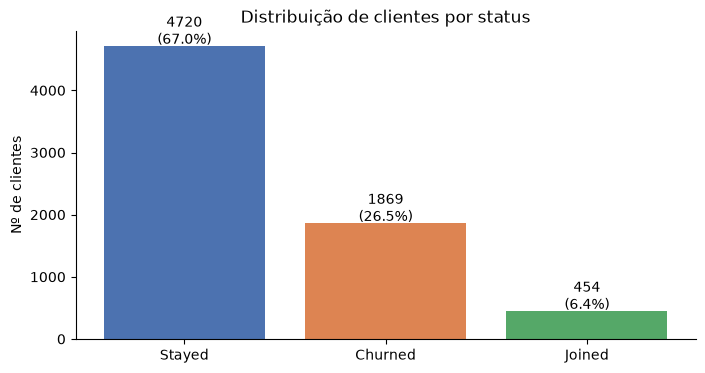

In [5]:
fig, ax = plt.subplots()
contagem = df["status_customer_status"].value_counts()
ax.bar(contagem.index, contagem.to_numpy(), color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Distribuição de clientes por status")
ax.set_ylabel("Nº de clientes")
for i, v in enumerate(contagem.to_numpy()):
    ax.text(i, v + 30, f"{v}\n({v / len(df):.1%})", ha="center")
plt.show()

## 4. Perfil demográfico

Idade, gênero, se é idoso (`senior_citizen`), se tem dependentes e se é casado.

Idade (demographics_age):
count    7043.0
mean       46.5
std        16.8
min        19.0
25%        32.0
50%        46.0
75%        60.0
max        80.0
Name: demographics_age, dtype: float64


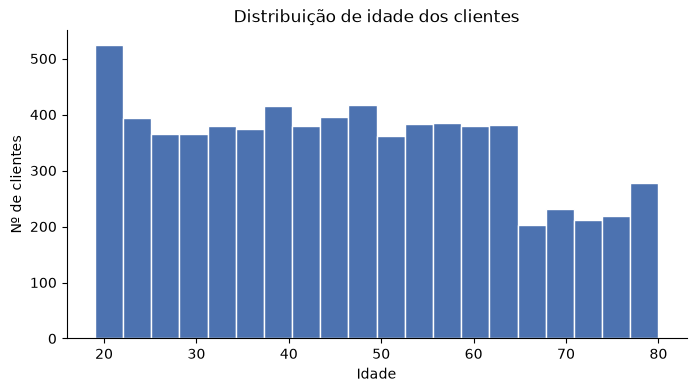

In [6]:
print("Idade (demographics_age):")
print(df["demographics_age"].describe().round(1))

fig, ax = plt.subplots()
ax.hist(df["demographics_age"], bins=20, color="#4C72B0", edgecolor="white")
ax.set_title("Distribuição de idade dos clientes")
ax.set_xlabel("Idade")
ax.set_ylabel("Nº de clientes")
plt.show()

In [7]:
def taxa_churn_por_categoria(coluna: str, top_n: int | None = None) -> pd.DataFrame:
    """Retorna contagem, taxa de churn e ordena da maior para a menor taxa."""
    resumo = (
        df.groupby(coluna, observed=True)["status_churn_value"]
        .agg(["count", "mean"])
        .rename(columns={"count": "n_clientes", "mean": "taxa_churn"})
        .sort_values("taxa_churn", ascending=False)
    )
    if top_n:
        resumo = resumo.head(top_n)
    return resumo


def plot_churn_por_categoria(coluna: str, titulo: str, top_n: int | None = None) -> None:
    resumo = taxa_churn_por_categoria(coluna, top_n)
    fig, ax = plt.subplots()
    ax.barh(resumo.index.astype(str), resumo["taxa_churn"].to_numpy(), color="#C44E52")
    ax.axvline(
        taxa_churn,
        color="grey",
        linestyle="--",
        linewidth=1,
        label=f"Média geral ({taxa_churn:.1%})",
    )
    ax.set_xlabel("Taxa de churn")
    ax.set_title(titulo)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(resumo.assign(taxa_churn=lambda d: (d["taxa_churn"] * 100).round(1).astype(str) + "%"))


print("Funções auxiliares definidas: taxa_churn_por_categoria(), plot_churn_por_categoria()")

Funções auxiliares definidas: taxa_churn_por_categoria(), plot_churn_por_categoria()


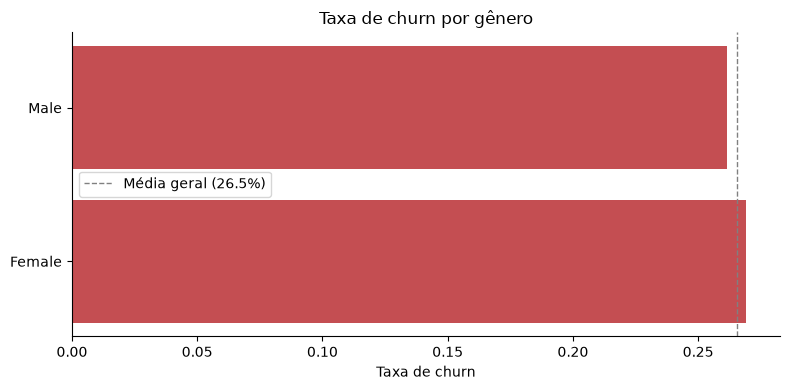

                     n_clientes taxa_churn
demographics_gender                       
Female                     3488      26.9%
Male                       3555      26.2%


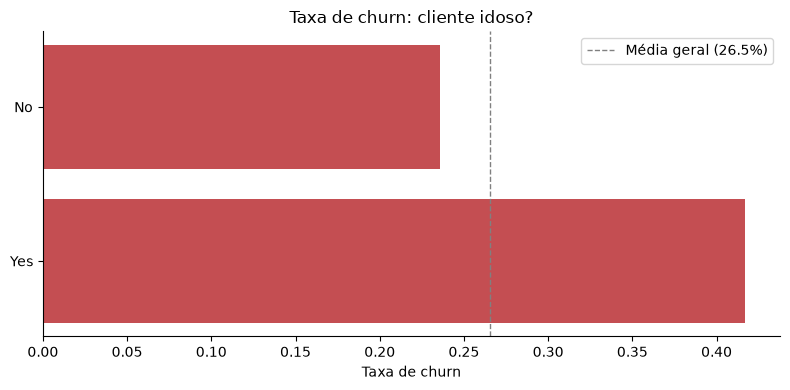

                             n_clientes taxa_churn
demographics_senior_citizen                       
Yes                                1142      41.7%
No                                 5901      23.6%


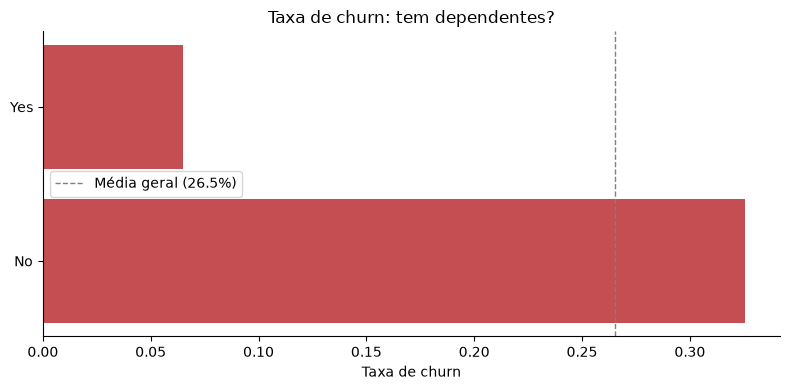

                         n_clientes taxa_churn
demographics_dependents                       
No                             5416      32.6%
Yes                            1627       6.5%


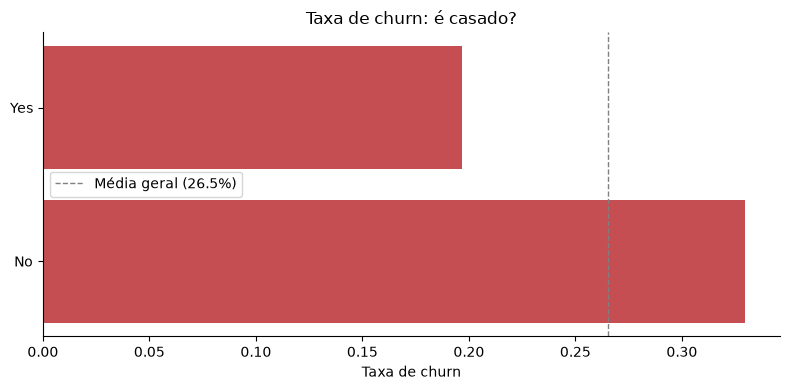

                      n_clientes taxa_churn
demographics_married                       
No                          3641      33.0%
Yes                         3402      19.7%


In [8]:
for coluna, titulo in [
    ("demographics_gender", "Taxa de churn por gênero"),
    ("demographics_senior_citizen", "Taxa de churn: cliente idoso?"),
    ("demographics_dependents", "Taxa de churn: tem dependentes?"),
    ("demographics_married", "Taxa de churn: é casado?"),
]:
    plot_churn_por_categoria(coluna, titulo)

## 5. Contrato, serviços e cobrança

Foco nas variáveis que a operadora controla diretamente: tipo de contrato, tipo de internet, forma de pagamento, tempo de casa (tenure) e valores cobrados.

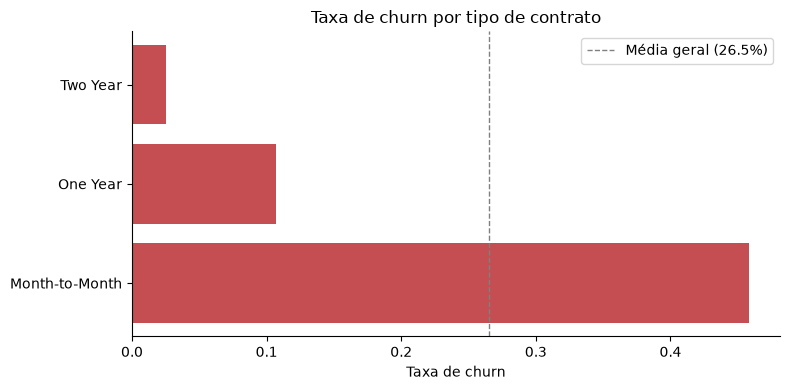

                   n_clientes taxa_churn
services_contract                       
Month-to-Month           3610      45.8%
One Year                 1550      10.7%
Two Year                 1883       2.5%


In [9]:
plot_churn_por_categoria("services_contract", "Taxa de churn por tipo de contrato")

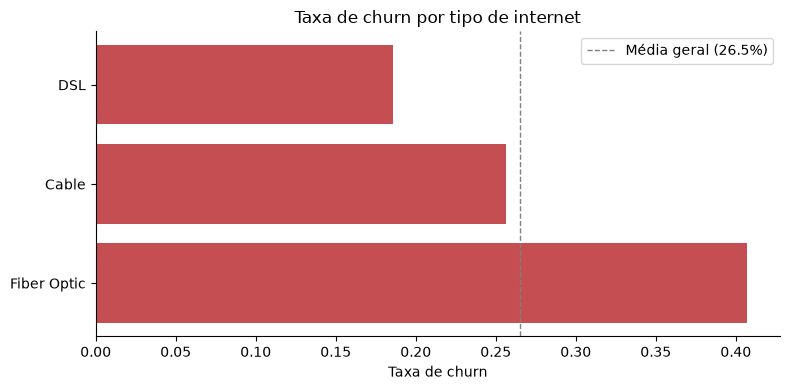

                        n_clientes taxa_churn
services_internet_type                       
Fiber Optic                   3035      40.7%
Cable                          830      25.7%
DSL                           1652      18.6%


In [10]:
plot_churn_por_categoria("services_internet_type", "Taxa de churn por tipo de internet")

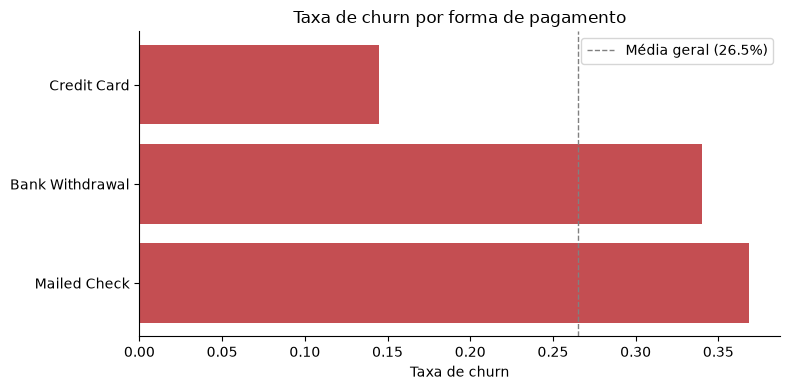

                         n_clientes taxa_churn
services_payment_method                       
Mailed Check                    385      36.9%
Bank Withdrawal                3909      34.0%
Credit Card                    2749      14.5%


In [11]:
plot_churn_por_categoria("services_payment_method", "Taxa de churn por forma de pagamento")

Tenure (meses de casa), descrito por status de churn:
                     count  mean   std  min   25%   50%   75%   max
status_churn_label                                                 
No                  5174.0  37.6  24.1  1.0  15.0  38.0  61.0  72.0
Yes                 1869.0  18.0  19.5  1.0   2.0  10.0  29.0  72.0


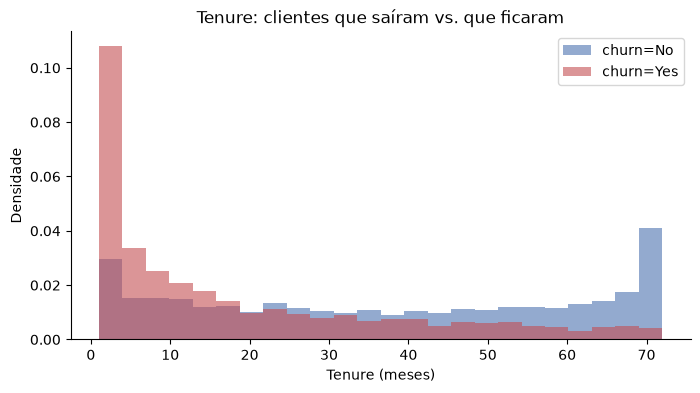

In [12]:
print("Tenure (meses de casa), descrito por status de churn:")
print(df.groupby("status_churn_label")["services_tenure_in_months"].describe().round(1))

fig, ax = plt.subplots()
for label, cor in [("No", "#4C72B0"), ("Yes", "#C44E52")]:
    subset = df.loc[df["status_churn_label"] == label, "services_tenure_in_months"]
    ax.hist(subset, bins=24, alpha=0.6, label=f"churn={label}", color=cor, density=True)
ax.set_xlabel("Tenure (meses)")
ax.set_ylabel("Densidade")
ax.set_title("Tenure: clientes que saíram vs. que ficaram")
ax.legend()
plt.show()

In [13]:
faixa_tenure = pd.cut(
    df["services_tenure_in_months"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"],
)
print("Taxa de churn (%) por tipo de contrato x faixa de tenure:")
tabela_interacao = (
    (
        df.groupby(["services_contract", faixa_tenure], observed=True)["status_churn_value"].mean()
        * 100
    )
    .round(1)
    .unstack()
)
print(tabela_interacao)

Taxa de churn (%) por tipo de contrato x faixa de tenure:
services_tenure_in_months  0-12  13-24  25-48  49-72
services_contract                                   
Month-to-Month             53.5   40.5   36.9   30.1
One Year                    8.9    7.4   10.1   12.8
Two Year                    0.0    0.0    1.8    3.2


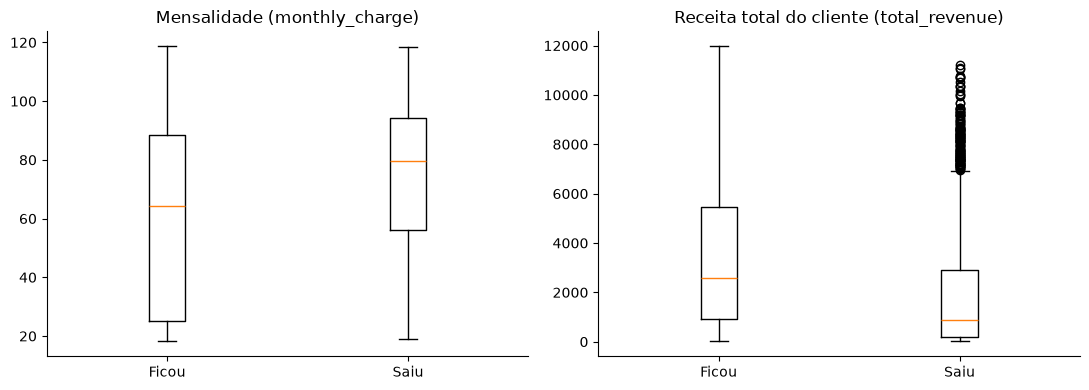

                    services_monthly_charge  services_total_revenue
status_churn_label                                                 
No                                    64.43                 2579.32
Yes                                   79.65                  893.55


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, coluna, titulo in [
    (axes[0], "services_monthly_charge", "Mensalidade (monthly_charge)"),
    (axes[1], "services_total_revenue", "Receita total do cliente (total_revenue)"),
]:
    dados = [
        df.loc[df["status_churn_label"] == "No", coluna].dropna(),
        df.loc[df["status_churn_label"] == "Yes", coluna].dropna(),
    ]
    ax.boxplot(dados, tick_labels=["Ficou", "Saiu"])
    ax.set_title(titulo)
plt.tight_layout()
plt.show()

colunas_resumo = ["services_monthly_charge", "services_total_revenue"]
print(df.groupby("status_churn_label")[colunas_resumo].median().round(2))

## 6. Satisfação, churn score (da IBM) e CLTV

As três colunas de "avaliação" da base vêm prontas da IBM: `status_satisfaction_score` (nota 1-5), `status_churn_score` (0-100) e `status_cltv` (customer lifetime value estimado). Antes de tratá-las como features, vale checar **quando** cada uma parece ter sido medida — se o valor só faz sentido depois do evento de churn, usá-la como feature seria vazamento de um processo/modelo anterior.

In [15]:
print("Taxa de churn por nota de satisfação (status_satisfaction_score):")
resumo_satisfacao = (
    df.groupby("status_satisfaction_score")["status_churn_value"]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_clientes", "mean": "taxa_churn"})
)
print(
    resumo_satisfacao.assign(
        taxa_churn=lambda d: (d["taxa_churn"] * 100).round(1).astype(str) + "%"
    )
)

print()
print("Satisfação por status do cliente:")
print(df.groupby("status_customer_status")["status_satisfaction_score"].describe().round(2))

Taxa de churn por nota de satisfação (status_satisfaction_score):
                           n_clientes taxa_churn
status_satisfaction_score                       
1                                 922     100.0%
2                                 518     100.0%
3                                2665      16.1%
4                                1789       0.0%
5                                1149       0.0%

Satisfação por status do cliente:
                         count  mean   std  min  25%  50%  75%  max
status_customer_status                                             
Churned                 1869.0  1.74  0.81  1.0  1.0  2.0  2.0  3.0
Joined                   454.0  3.97  0.82  3.0  3.0  4.0  5.0  5.0
Stayed                  4720.0  3.77  0.78  3.0  3.0  4.0  4.0  5.0


A separação é **perfeita nos extremos**: 100% dos clientes com nota 1-2 cancelaram, 0% dos com nota 4-5, e quem cancelou tem nota máxima 3. Nenhuma pesquisa de satisfação real (medida antes do evento) separa assim — essa nota foi atribuída junto/depois do desfecho de churn. Ou seja: **`status_satisfaction_score` é vazamento**, na mesma categoria do `status_churn_score` abaixo, e não pode ser usada como feature.

status_churn_score (0-100) por status_churn_label:
                     count  mean   std   min   25%   50%   75%   max
status_churn_label                                                  
No                  5174.0  50.1  17.7   5.0  35.0  50.0  66.0  80.0
Yes                 1869.0  81.8   9.2  65.0  74.0  83.0  90.0  96.0


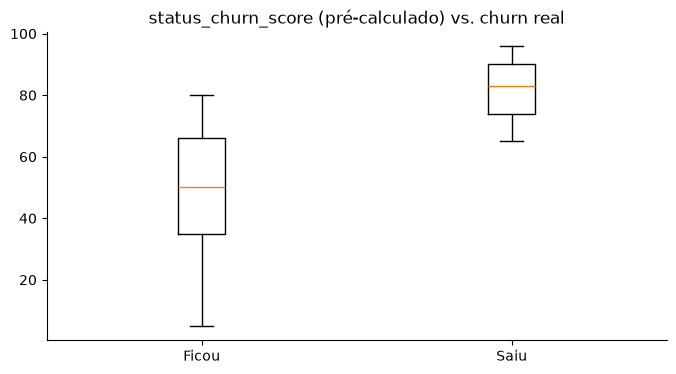

In [16]:
print("status_churn_score (0-100) por status_churn_label:")
print(df.groupby("status_churn_label")["status_churn_score"].describe().round(1))

fig, ax = plt.subplots()
dados = [
    df.loc[df["status_churn_label"] == "No", "status_churn_score"],
    df.loc[df["status_churn_label"] == "Yes", "status_churn_score"],
]
ax.boxplot(dados, tick_labels=["Ficou", "Saiu"])
ax.set_title("status_churn_score (pré-calculado) vs. churn real")
plt.show()

In [17]:
print("status_cltv (customer lifetime value) por status_churn_label:")
print(df.groupby("status_churn_label")["status_cltv"].describe().round(0))

status_cltv (customer lifetime value) por status_churn_label:
                     count    mean     std     min     25%     50%     75%  \
status_churn_label                                                           
No                  5174.0  4491.0  1168.0  2003.0  3644.0  4620.0  5435.0   
Yes                 1869.0  4149.0  1189.0  2003.0  3101.0  4238.0  5166.0   

                       max  
status_churn_label          
No                  6500.0  
Yes                 6484.0  


## 7. Motivos de cancelamento (apenas quem já saiu)

Diferente da maioria dos datasets de churn, este traz `status_churn_category` e `status_churn_reason` — o motivo declarado pelo cliente que cancelou. É a variável mais direta para entender **por que** os clientes saem (só existe para `status_customer_status == "Churned"`).

Clientes que cancelaram: 1869 (26.5% da base)

Categoria do motivo de cancelamento:
status_churn_category
Competitor         841
Attitude           314
Dissatisfaction    303
Price              211
Other              200
Name: count, dtype: int64


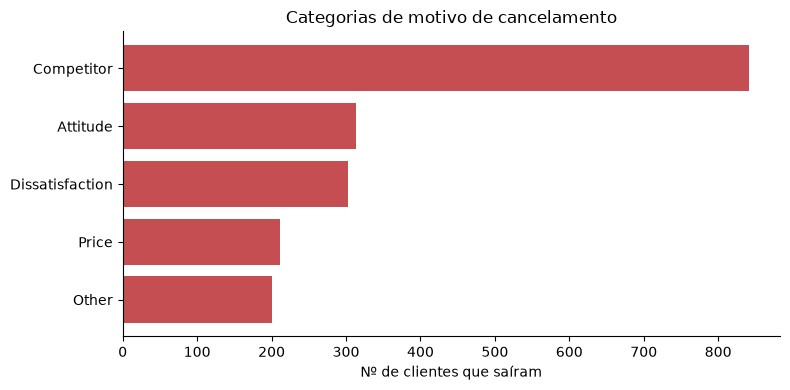

In [18]:
churned = df.loc[df["status_customer_status"] == "Churned"]
print(f"Clientes que cancelaram: {len(churned)} ({len(churned) / len(df):.1%} da base)")
print()

print("Categoria do motivo de cancelamento:")
cat_counts = churned["status_churn_category"].value_counts()
print(cat_counts)

fig, ax = plt.subplots()
ax.barh(cat_counts.index[::-1], cat_counts.to_numpy()[::-1], color="#C44E52")
ax.set_title("Categorias de motivo de cancelamento")
ax.set_xlabel("Nº de clientes que saíram")
plt.tight_layout()
plt.show()

Top 10 motivos específicos de cancelamento:
status_churn_reason
Competitor had better devices                313
Competitor made better offer                 311
Attitude of support person                   220
Don't know                                   130
Competitor offered more data                 117
Competitor offered higher download speeds    100
Attitude of service provider                  94
Price too high                                78
Product dissatisfaction                       77
Network reliability                           72
Name: count, dtype: int64


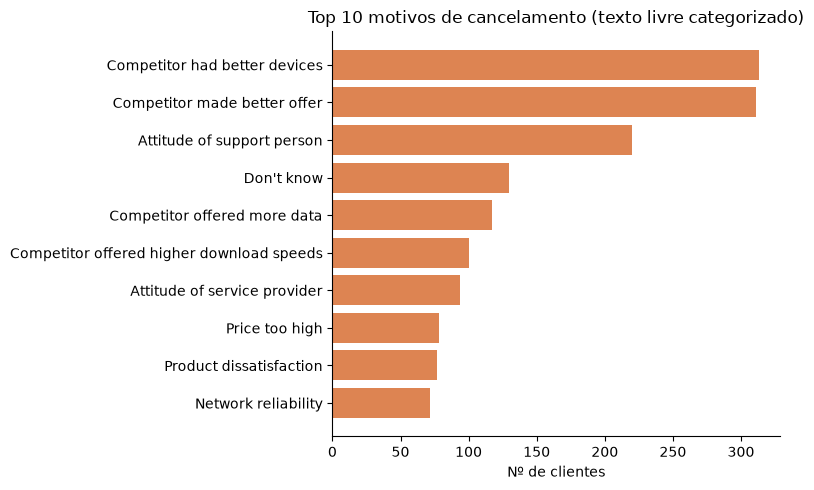

In [19]:
print("Top 10 motivos específicos de cancelamento:")
reason_counts = churned["status_churn_reason"].value_counts().head(10)
print(reason_counts)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(reason_counts.index[::-1], reason_counts.to_numpy()[::-1], color="#DD8452")
ax.set_title("Top 10 motivos de cancelamento (texto livre categorizado)")
ax.set_xlabel("Nº de clientes")
plt.tight_layout()
plt.show()

## 8. Correlações entre variáveis numéricas e churn

Todas as colunas numéricas com potencial de sinal entram aqui — incluindo as quatro de cobrança acumulada (`total_refunds`, `total_extra_data_charges`, `avg/total_long_distance_charges`). Um detalhe de leitura importante: a **mensalidade** correlaciona *positivamente* com churn (paga mais → sai mais), enquanto os **acumulados** (`total_charges`, `total_revenue`, `total_long_distance_charges`) correlacionam *negativamente* — não porque gastar proteja, mas porque acumulado é proxy de tenure: cliente antigo acumulou mais e é justamente quem menos sai.

Correlação (Pearson) de cada variável numérica com status_churn_value:
status_satisfaction_score                    -0.755
status_churn_score                            0.661
services_tenure_in_months                    -0.353
services_number_of_referrals                 -0.287
services_total_long_distance_charges         -0.224
services_total_revenue                       -0.223
demographics_number_of_dependents            -0.219
services_total_charges                       -0.199
services_monthly_charge                       0.193
status_cltv                                  -0.127
demographics_age                              0.116
populations_population                        0.052
services_avg_monthly_gb_download              0.049
services_total_refunds                       -0.034
services_avg_monthly_long_distance_charges    0.008
services_total_extra_data_charges             0.007
Name: status_churn_value, dtype: float64


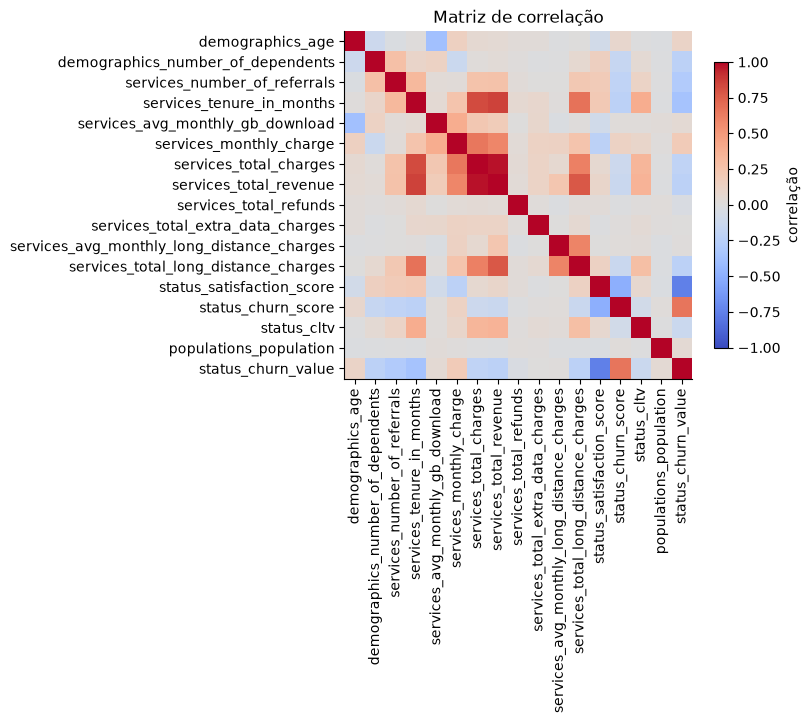

In [20]:
colunas_numericas = [
    "demographics_age",
    "demographics_number_of_dependents",
    "services_number_of_referrals",
    "services_tenure_in_months",
    "services_avg_monthly_gb_download",
    "services_monthly_charge",
    "services_total_charges",
    "services_total_revenue",
    "services_total_refunds",
    "services_total_extra_data_charges",
    "services_avg_monthly_long_distance_charges",
    "services_total_long_distance_charges",
    "status_satisfaction_score",
    "status_churn_score",
    "status_cltv",
    "populations_population",
    "status_churn_value",
]

corr = df[colunas_numericas].corr()
corr_com_churn = (
    corr["status_churn_value"].drop("status_churn_value").sort_values(key=abs, ascending=False)
)
print("Correlação (Pearson) de cada variável numérica com status_churn_value:")
print(corr_com_churn.round(3))

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(colunas_numericas)))
ax.set_xticklabels(colunas_numericas, rotation=90)
ax.set_yticks(range(len(colunas_numericas)))
ax.set_yticklabels(colunas_numericas)
fig.colorbar(im, ax=ax, shrink=0.8, label="correlação")
ax.set_title("Matriz de correlação")
plt.tight_layout()
plt.show()

## 9. Geografia

A base tem `locations_state`/`locations_city`/`zip_code` e `populations_population` (densidade populacional do CEP). Confirmamos primeiro a cobertura geográfica antes de decidir se vale a pena explorar mais.

In [21]:
print(f"Estados distintos: {df['locations_state'].nunique()} -> {df['locations_state'].unique()}")
print(f"Cidades distintas: {df['locations_city'].nunique()}")
print()
print("Top 10 cidades por nº de clientes e taxa de churn:")
top_cidades = taxa_churn_por_categoria("locations_city").sort_values("n_clientes", ascending=False)
print(top_cidades.head(10))

Estados distintos: 1 -> ['California']
Cidades distintas: 1106

Top 10 cidades por nº de clientes e taxa de churn:
                n_clientes  taxa_churn
locations_city                        
Los Angeles            293    0.266212
San Diego              285    0.649123
San Jose               112    0.258929
Sacramento             108    0.240741
San Francisco          104    0.298077
Fresno                  61    0.213115
Long Beach              60    0.250000
Oakland                 52    0.250000
Escondido               51    0.313725
Stockton                44    0.272727


## 10. Cobertura completa: colunas de serviço restantes

Até aqui só olhamos as variáveis com maior suspeita de sinal. Faltam 15 colunas categóricas (flags de serviço, add-ons e afins) que não foram examinadas — incluindo `services_internet_service` (Yes/No: o cliente tem internet?), que é a coluna-mãe de `services_internet_type`. Fechando a cobertura por completude.

In [22]:
colunas_categoricas_restantes = [
    "demographics_under_30",
    "services_phone_service",
    "services_multiple_lines",
    "services_internet_service",
    "services_referred_a_friend",
    "services_online_security",
    "services_online_backup",
    "services_device_protection_plan",
    "services_premium_tech_support",
    "services_streaming_tv",
    "services_streaming_movies",
    "services_streaming_music",
    "services_unlimited_data",
    "services_paperless_billing",
    "services_offer",
]

for coluna in colunas_categoricas_restantes:
    print(f"--- {coluna} ---")
    resumo = taxa_churn_por_categoria(coluna).assign(
        taxa_churn=lambda d: (d["taxa_churn"] * 100).round(1).astype(str) + "%"
    )
    print(resumo)
    print()

print("Consistência services_internet_service == 'No' <=> services_internet_type nulo:")
print((df["services_internet_service"].eq("No") == df["services_internet_type"].isna()).all())

--- demographics_under_30 ---
                       n_clientes taxa_churn
demographics_under_30                       
No                           5642      27.7%
Yes                          1401      21.7%

--- services_phone_service ---
                        n_clientes taxa_churn
services_phone_service                       
Yes                           6361      26.7%
No                             682      24.9%

--- services_multiple_lines ---
                         n_clientes taxa_churn
services_multiple_lines                       
Yes                            2971      28.6%
No                             4072      25.0%

--- services_internet_service ---
                           n_clientes taxa_churn
services_internet_service                       
Yes                              5517      31.8%
No                               1526       7.4%

--- services_referred_a_friend ---
                            n_clientes taxa_churn
services_referred_a_friend          

## 11. Variáveis numéricas restantes

Forma da distribuição das colunas numéricas que ainda não tinham sido examinadas individualmente. A associação de todas com o churn já apareceu na matriz da seção 8 — aqui o foco é a distribuição (caudas, zeros estruturais, escala), que importa para o pré-processamento.

                                             count      mean       std   min  \
services_avg_monthly_long_distance_charges  7043.0     22.96     15.45   0.0   
services_total_long_distance_charges        7043.0    749.10    846.66   0.0   
services_number_of_referrals                7043.0      1.95      3.00   0.0   
services_total_refunds                      7043.0      1.96      7.90   0.0   
services_total_extra_data_charges           7043.0      6.86     25.10   0.0   
services_avg_monthly_gb_download            7043.0     20.52     20.42   0.0   
populations_population                      7043.0  22139.81  21152.17  11.0   
demographics_number_of_dependents           7043.0      0.47      0.96   0.0   

                                                25%       50%       75%  \
services_avg_monthly_long_distance_charges     9.21     22.89     36.39   
services_total_long_distance_charges          70.54    401.44   1191.10   
services_number_of_referrals                   0.00   

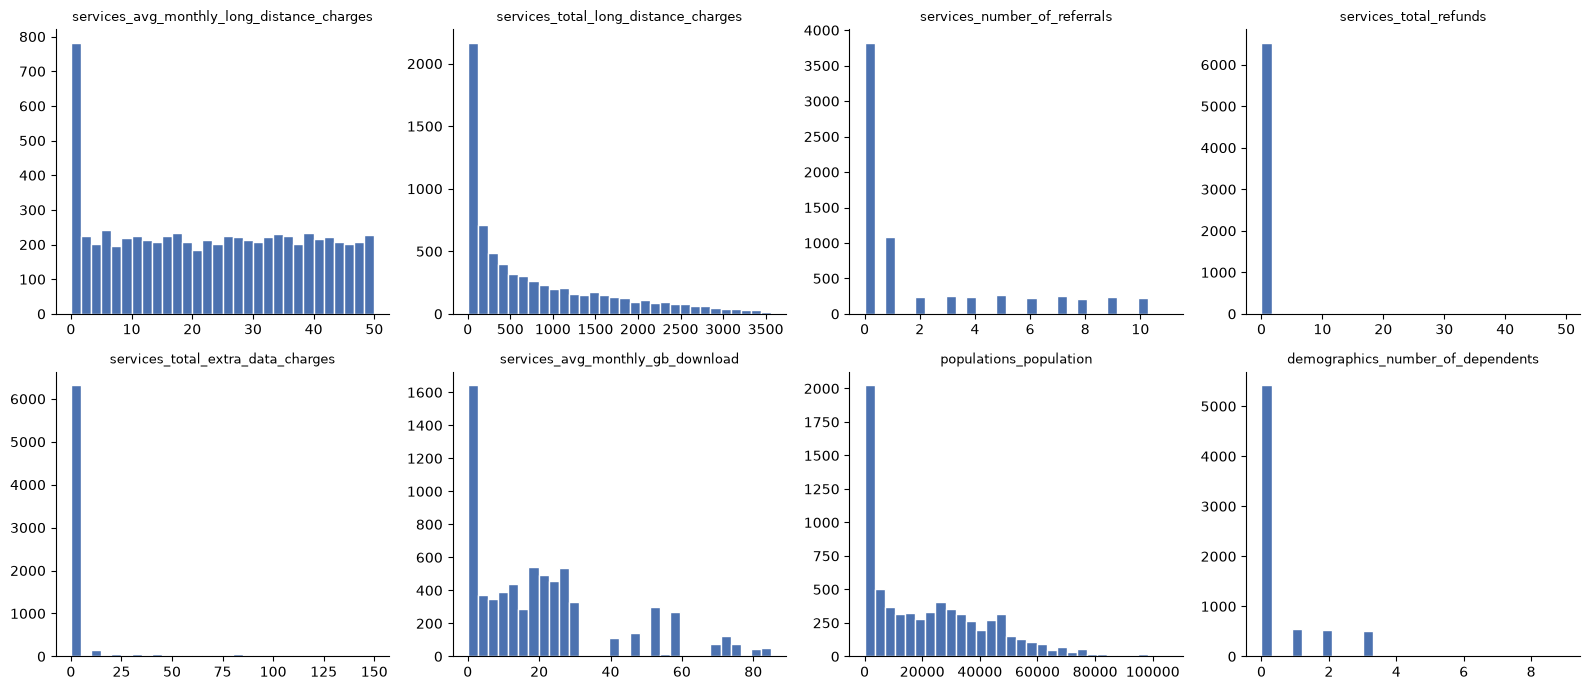

In [23]:
colunas_numericas_restantes = [
    "services_avg_monthly_long_distance_charges",
    "services_total_long_distance_charges",
    "services_number_of_referrals",
    "services_total_refunds",
    "services_total_extra_data_charges",
    "services_avg_monthly_gb_download",
    "populations_population",
    "demographics_number_of_dependents",
]
print(df[colunas_numericas_restantes].describe().T.round(2))

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, coluna in zip(axes.flat, colunas_numericas_restantes, strict=True):
    ax.hist(df[coluna], bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(coluna, fontsize=9)
plt.tight_layout()
plt.show()

## 12. Qualidade: valores inválidos, duplicatas e consistência interna

Além de contar nulos (seção 2), checamos se os valores fazem sentido dentro do domínio esperado e se colunas relacionadas são consistentes entre si.

In [24]:
checks = {
    "idade fora de [0, 120]": ((df["demographics_age"] < 0) | (df["demographics_age"] > 120)).sum(),
    "monthly_charge <= 0": (df["services_monthly_charge"] <= 0).sum(),
    "total_charges < 0": (df["services_total_charges"] < 0).sum(),
    "total_refunds < 0": (df["services_total_refunds"] < 0).sum(),
    "tenure fora de [0, 100]": (
        (df["services_tenure_in_months"] < 0) | (df["services_tenure_in_months"] > 100)
    ).sum(),
    "satisfaction_score fora de [1, 5]": (
        (df["status_satisfaction_score"] < 1) | (df["status_satisfaction_score"] > 5)
    ).sum(),
    "churn_score fora de [0, 100]": (
        (df["status_churn_score"] < 0) | (df["status_churn_score"] > 100)
    ).sum(),
    "linhas 100% duplicadas": df.duplicated().sum(),
}
for descricao, n in checks.items():
    marca = "✓" if n == 0 else "✗"
    print(f"{marca} {descricao}: {n}")

print()
print("Consistência demographics_under_30 == (age < 30):")
print((df["demographics_under_30"].eq("Yes") == (df["demographics_age"] < 30)).all())

print()
print("Consistência services_referred_a_friend == (number_of_referrals > 0):")
print(
    (df["services_referred_a_friend"].eq("Yes") == (df["services_number_of_referrals"] > 0)).all()
)

print()
print("Zeros estruturais (zero <=> serviço inexistente, não é dado faltante):")
print(
    "  gb_download == 0 <=> sem internet:",
    (
        df["services_avg_monthly_gb_download"].eq(0) == df["services_internet_service"].eq("No")
    ).all(),
)
print(
    "  avg_long_distance == 0 <=> sem telefone:",
    (
        df["services_avg_monthly_long_distance_charges"].eq(0)
        == df["services_phone_service"].eq("No")
    ).all(),
)

print()
print("Identidade contábil: total_revenue == total_charges - refunds + extra_data + long_distance:")
reconstrucao = (
    df["services_total_charges"]
    - df["services_total_refunds"]
    + df["services_total_extra_data_charges"]
    + df["services_total_long_distance_charges"]
)
print(f"  diferença máxima absoluta: {(df['services_total_revenue'] - reconstrucao).abs().max()}")

print()
print("Identidade: total_long_distance == avg_monthly_long_distance * tenure:")
diff_long = (
    df["services_avg_monthly_long_distance_charges"] * df["services_tenure_in_months"]
    - df["services_total_long_distance_charges"]
)
print(f"  diferença máxima absoluta: {diff_long.abs().max().round(4)}")

print()
print("total_charges vs. monthly_charge * tenure (diferença absoluta, não é identidade exata):")
esperado = df["services_monthly_charge"] * df["services_tenure_in_months"]
print((df["services_total_charges"] - esperado).abs().describe().round(2))

✓ idade fora de [0, 120]: 0
✓ monthly_charge <= 0: 0
✓ total_charges < 0: 0
✓ total_refunds < 0: 0
✓ tenure fora de [0, 100]: 0
✓ satisfaction_score fora de [1, 5]: 0
✓ churn_score fora de [0, 100]: 0
✓ linhas 100% duplicadas: 0

Consistência demographics_under_30 == (age < 30):
True

Consistência services_referred_a_friend == (number_of_referrals > 0):
True

Zeros estruturais (zero <=> serviço inexistente, não é dado faltante):
  gb_download == 0 <=> sem internet: True
  avg_long_distance == 0 <=> sem telefone: True

Identidade contábil: total_revenue == total_charges - refunds + extra_data + long_distance:
  diferença máxima absoluta: 0.0

Identidade: total_long_distance == avg_monthly_long_distance * tenure:
  diferença máxima absoluta: 0.0

total_charges vs. monthly_charge * tenure (diferença absoluta, não é identidade exata):
count    7043.00
mean       45.02
std        49.89
min         0.00
25%         9.35
50%        28.60
75%        63.62
max       373.25
dtype: float64


## 13. Cardinalidade: identificadores e colunas constantes

Colunas com cardinalidade 1 (constantes) ou igual ao nº de linhas (identificadores) não carregam sinal preditivo e são candidatas naturais a descarte no pipeline de features.

In [25]:
colunas_id_ou_constantes = [
    "customer_id",
    "locations_location_id",
    "services_service_id",
    "status_status_id",
    "populations_id",
    "zip_code",
    "locations_city",
    "locations_state",
    "locations_country",
    "locations_lat_long",
    "locations_latitude",
    "locations_longitude",
    "services_quarter",
    "status_quarter",
    "locations_count",
    "demographics_count",
    "services_count",
    "status_count",
]

resumo_cardinalidade = pd.DataFrame(
    {
        "n_unicos": [df[c].nunique() for c in colunas_id_ou_constantes],
        "exemplo_valor": [df[c].iloc[0] for c in colunas_id_ou_constantes],
    },
    index=colunas_id_ou_constantes,
).sort_values("n_unicos")

print(resumo_cardinalidade)
print()
print("Colunas com valor único (constantes, zero variância):")
constantes = resumo_cardinalidade.loc[resumo_cardinalidade["n_unicos"] == 1].index.tolist()
print(constantes)
print()
print("Colunas com 1 valor por cliente (identificadores, não features):")
identificadoras = resumo_cardinalidade.loc[
    resumo_cardinalidade["n_unicos"] == len(df)
].index.tolist()
print(identificadoras)

# Confirma que nenhuma coluna constante ficou fora da lista de candidatas
constantes_reais = [c for c in df.columns if df[c].nunique() == 1]
print()
print(f"Constantes na base inteira: {len(constantes_reais)} — todas na lista acima:")
print(sorted(constantes_reais) == sorted(constantes))

                       n_unicos          exemplo_valor
locations_state               1             California
status_quarter                1                     Q3
locations_count               1                      1
demographics_count            1                      1
services_quarter              1                     Q3
locations_country             1          United States
status_count                  1                      1
services_count                1                      1
locations_city             1106            Los Angeles
locations_longitude        1625            -118.156582
zip_code                   1625                  90022
populations_id             1625                     21
locations_latitude         1626               34.02381
locations_lat_long         1679  34.02381, -118.156582
customer_id                7043             8779-QRDMV
locations_location_id      7043             OXCZEW7397
status_status_id           7043             SWSORB1252
services_s

## 14. Data readiness: schema esperado (via `pandera`)

O schema de domínio levantado aqui foi promovido para um contrato de dados real em `src/data/schema.py` ([spec 0004](../specs/0004-schema-dados-processados/spec.md)), com testes em `tests/data/test_schema.py`. Esta célula só reutiliza esse módulo para validar a base carregada neste notebook.

In [26]:
import pandera.pandas as pa

from src.data.schema import validar

try:
    validar(df)
    print("✓ Dataframe passou em todas as regras de domínio verificadas.")
except pa.errors.SchemaErrors as erro:
    print("✗ Falhas encontradas:")
    print(erro.failure_cases)

✓ Dataframe passou em todas as regras de domínio verificadas.


In [27]:
n_fora_de_faixa = sum(1 for v in checks.values() if v > 0)
print("Resumo de data readiness:")
print(f"- Linhas 100% duplicadas: {df.duplicated().sum()}")
print(f"- Colunas fora de faixa de domínio: {n_fora_de_faixa} de {len(checks)} checagens")
print(f"- Colunas constantes (candidatas a descarte): {constantes}")
print(f"- Colunas identificadoras (candidatas a descarte como feature): {identificadoras}")
print(
    "- Colunas de vazamento (não usar como feature): "
    "['status_satisfaction_score', 'status_churn_score', 'status_cltv', "
    "'status_churn_category', 'status_churn_reason']"
)
print(
    "- Redundâncias (manter só uma de cada par): under_30 <=> age < 30; "
    "internet_service == 'No' <=> internet_type nulo; "
    "referred_a_friend <=> number_of_referrals > 0; "
    "total_revenue é identidade contábil das demais colunas de cobrança"
)
print(
    "- Nulos legítimos (não indicam problema): status_churn_reason/category "
    "(só existem p/ churned), services_offer (null = sem oferta), "
    "services_internet_type (null = sem internet)"
)

Resumo de data readiness:
- Linhas 100% duplicadas: 0
- Colunas fora de faixa de domínio: 0 de 8 checagens
- Colunas constantes (candidatas a descarte): ['locations_state', 'status_quarter', 'locations_count', 'demographics_count', 'services_quarter', 'locations_country', 'status_count', 'services_count']
- Colunas identificadoras (candidatas a descarte como feature): ['customer_id', 'locations_location_id', 'status_status_id', 'services_service_id']
- Colunas de vazamento (não usar como feature): ['status_satisfaction_score', 'status_churn_score', 'status_cltv', 'status_churn_category', 'status_churn_reason']
- Redundâncias (manter só uma de cada par): under_30 <=> age < 30; internet_service == 'No' <=> internet_type nulo; referred_a_friend <=> number_of_referrals > 0; total_revenue é identidade contábil das demais colunas de cobrança
- Nulos legítimos (não indicam problema): status_churn_reason/category (só existem p/ churned), services_offer (null = sem oferta), services_internet_ty

## 15. Storytelling: o que a EDA revela

A exploração acima foi livre, seção por seção — e depois fechada com uma cobertura completa (seções 10-14) para não deixar suposição sem checar. Fechando o raciocínio: qual é a história que os dados contam, e o que ela implica para o trabalho de modelagem que vem a seguir?

### O tamanho do problema

De 7.043 clientes, **1.869 já cancelaram (26,5%)** e outros 454 (6,4%) entraram recentemente (`Joined`). É uma base desbalanceada, mas não a ponto de exigir técnicas agressivas de balanceamento — 1 em cada 4 clientes é churn.

### Quem sai: um perfil bem definido

Cruzando cada variável com a taxa de churn (seções 4-6, 8 e 10), o perfil de risco converge de forma consistente:

- **Contrato é o fator isolado mais forte**: Month-to-Month tem **45,8%** de churn, contra 10,7% (1 ano) e apenas 2,5% (2 anos). E o efeito se intensifica no início da relação: Month-to-Month **nos primeiros 12 meses chega a 53,5%**, enquanto contrato de 2 anos tem 0% de churn nos primeiros 24 meses.
- **Tempo de casa (tenure) confirma o mesmo padrão**: quem cancela tem mediana de **10 meses** de casa; quem fica, **38 meses**. O risco está concentrado no início da jornada do cliente.
- **Ter internet já é, por si só, fator de risco**: clientes com internet (`services_internet_service = Yes`) têm **31,8%** de churn contra apenas **7,4%** de quem não tem — o produto de internet concentra quase todo o problema de churn da operadora.
- **Fibra ótica** tem quase o dobro da taxa de churn da DSL (40,7% vs. 18,6%) — apesar de (ou por causa de) cobrar mais: mensalidade mediana de quem sai é **US$ 79,65**, contra **US$ 64,43** de quem fica.
- **Cobrança: o sinal está na mensalidade, não no acumulado**: `monthly_charge` correlaciona +0,193 com churn (paga mais → sai mais), enquanto os acumulados (`total_charges` −0,199, `total_revenue` −0,223, `total_long_distance_charges` −0,224) são negativos apenas por serem proxies de tenure — cliente antigo acumulou mais e é quem menos sai. `total_refunds`, `total_extra_data_charges` e `avg_monthly_long_distance_charges` não têm sinal (|r| < 0,04).
- **Forma de pagamento manual** (Mailed Check 36,9%, Bank Withdrawal 34,0%) perde feio para Credit Card (14,5%) — pagamento automático por cartão parece ser proxy de menor atrito/maior comprometimento.
- **Estrutura familiar protege**: ter dependentes derruba o churn de 32,6% para 6,5%; ser casado, de 33,0% para 19,7%. Ser idoso quase dobra o risco (41,7% vs. 23,6%). Gênero não importa (26,2% vs. 26,9%) — não é uma variável útil para o modelo.
- **Add-ons de suporte/segurança são protetores**: `online_security` (31,3% sem vs. 14,6% com) e `premium_tech_support` (31,2% vs. 15,2%) reduzem o churn à metade — indício de que suporte técnico ativo aumenta a percepção de valor. Indicação de amigo (`referred_a_friend`) também protege (32,6% vs. 19,4%).
- **Achado contra-intuitivo**: `paperless_billing` (33,6% vs. 16,3%) e `unlimited_data` (31,7% vs. 16,0%) têm churn **maior** entre quem tem o serviço/opção — em boa parte porque quem tem essas opções é quem tem internet (o grupo de 31,8% de churn); não é uma relação causal direta, mas fica registrado.
- **`services_offer` é um sinal muito forte**: entre os 45% de clientes com alguma oferta promocional aplicada, "Offer E" tem **52,9%** de churn contra só 6,7% da "Offer A" — sugere que certas campanhas atraem justamente o perfil que depois cancela.
- **Geografia não ajuda**: a base cobre um único estado (Califórnia) e um único país (`locations_country` é constante). Não há variação de estado para explorar; a variação por cidade existe mas com N pequeno por cidade (ex.: San Diego com 64,9% de churn em apenas 285 clientes é chamativo, mas não dá para confiar sem mais dados).

### Por que sai: a variável que a maioria dos datasets de churn não tem

Esta base traz o motivo declarado do cancelamento (`status_churn_category`/`status_churn_reason`), só preenchido para os 1.869 que já saíram:

| Categoria | Clientes | % dos churns |
|---|---|---|
| Competitor | 841 | 45% |
| Attitude | 314 | 17% |
| Dissatisfaction | 303 | 16% |
| Price | 211 | 11% |
| Other | 200 | 11% |

Quase metade dos cancelamentos é para a **concorrência** — motivos específicos como "Competitor had better devices" (313) e "Competitor made better offer" (311) lideram. Somando "Attitude" + "Dissatisfaction" (33% dos churns), o segundo maior bloco é **qualidade de atendimento/produto**, não preço: "Price too high" é só 78 casos (4% do total de churns).

### Juntando as duas metades da história

O quadro que emerge: o cliente de maior risco é alguém em **contrato mensal**, **cedo na relação** (poucos meses de casa), com **fibra ótica** e **mensalidade alta**, pagando de forma **manual**, **sem dependentes** e **sem add-ons de suporte**. Esse cliente é justamente o mais vulnerável a uma oferta de concorrente — ele não tem barreira de saída (sem fidelidade contratual), já paga caro e não tem suporte técnico ativo para resolver fricções. Os motivos declarados confirmam: atendimento ruim ("Attitude") e insatisfação com o produto ("Dissatisfaction") somam um terço dos churns e funcionam como gatilho que empurra esse cliente a efetivamente atender a ligação do concorrente.

Isso muda a leitura ingênua de "os clientes saem porque a fibra é cara": o problema não é só preço, é **retenção estrutural** (falta de contrato longo, falta de add-ons que aumentam fricção de saída) combinada com **experiência** (atendimento/produto) — o preço é apenas o texto que o cliente usa para justificar quando os outros fatores já falharam.

### Qualidade e prontidão dos dados (seções 12-14)

A base passou em todas as checagens de domínio verificadas (idade, cobranças, tenure, satisfação, churn score, sem linhas duplicadas) — **não há problema de qualidade que bloqueie a modelagem**. Os pontos de atenção são estruturais, não de sujeira:

- **8 colunas constantes** (`services_quarter`, `status_quarter`, `locations_state`, `locations_country`, `locations_count`, `demographics_count`, `services_count`, `status_count` — todas com um único valor, ex. `"Q3"`, `"California"`, `"United States"` ou `1`) e **4 colunas identificadoras** (`customer_id`, `locations_location_id`, `services_service_id`, `status_status_id` — uma por cliente) não carregam sinal e devem ser descartadas do pipeline de features.
- **Redundâncias** (manter só uma de cada par): `demographics_under_30` ⇔ `demographics_age < 30`; `services_internet_service == "No"` ⇔ `services_internet_type` nulo; `services_referred_a_friend` ⇔ `services_number_of_referrals > 0`. Além disso, duas identidades exatas: `services_total_revenue` = `total_charges − refunds + extra_data + long_distance` e `total_long_distance_charges` = `avg_monthly_long_distance_charges × tenure` (diferença máxima 0,0 em ambas) — colinearidade perfeita se as parcelas também entrarem como features.
- **Zeros estruturais**: `avg_monthly_gb_download == 0` equivale exatamente a "sem internet" e `avg_monthly_long_distance_charges == 0` a "sem telefone" — o zero codifica ausência do serviço, não consumo baixo; tratar com cuidado em escalonamento/imputação.
- Nulos em `services_offer` (55%) e `services_internet_type` (22%) são **legítimos** (ausência de oferta / ausência de internet), não falta de dado — não tratar como "sujeira" a ser imputada às cegas.
- **Clientes `Joined` (454, tenure de 1-3 meses)**: estão rotulados como "não churn", mas não tiveram tempo de churnar (censura). A spec de modelagem precisa decidir explicitamente se eles entram no treino, saem, ou viram um recorte separado.

### Cuidado: vazamento de dados

- **`status_satisfaction_score`**: parecia o melhor preditor da base (correlação -0,755), mas a seção 6 mostra separação **perfeita nos extremos** — 100% de churn nas notas 1-2, 0% nas notas 4-5, e nota máxima 3 entre quem cancelou. Nenhuma pesquisa medida antes do evento separa assim: a nota foi atribuída junto/depois do desfecho. **É vazamento — não usar como feature.**
- **`status_churn_score`** (0-100, pré-calculado pela IBM): separa quem sai (média 81,8) de quem fica (média 50,1), correlação 0,661. É a saída de um modelo anterior sobre o mesmo alvo — vazamento. Pode servir como **benchmark a ser superado**, não como input.
- **`status_churn_category`/`status_churn_reason`**: só existem para quem já cancelou — indisponíveis no momento da previsão.
- **`status_cltv`**: está preenchido para todos os clientes (não é o caso dos motivos acima), mas é uma estimativa pré-calculada pela IBM com proveniência desconhecida — sem saber se o cálculo usa informação do desfecho, o conservador é também deixá-lo fora das features.

### Objetivo e próximos passos

**Hipótese de trabalho para a modelagem**: um modelo de churn com boa performance deve conseguir capturar a maior parte do sinal usando um núcleo pequeno de variáveis — `services_contract`, `services_tenure_in_months`, `services_internet_type`, `services_payment_method`, `services_monthly_charge`, `demographics_dependents`/`demographics_married`/`demographics_senior_citizen`, `services_online_security`/`services_premium_tech_support` — todas disponíveis no momento da previsão, sem vazamento, sem colunas constantes/identificadoras. Sem o `satisfaction_score` (vazamento), o teto de performance realista é mais baixo do que a correlação de -0,755 sugeria — e é exatamente por isso que o benchmark honesto passa a ser superar o `churn_score` da IBM usando só features legítimas.

Além do modelo preditivo, os dados sugerem duas frentes de ação de negócio distintas (não excludentes), que podem virar critérios de aceitação de uma spec futura:
1. **Retenção contratual**: incentivar migração de Month-to-Month para contratos anuais nos primeiros meses de casa, quando o risco é maior (53,5% de churn em Month-to-Month com até 12 meses).
2. **Retenção por experiência**: investigar atendimento (categoria "Attitude") e adoção de add-ons de suporte como alavanca tão ou mais importante que preço.